## Aspect-Based Sentiment Analysis Comparison
### **Course:** Applied Computer Science – Data & AI 6
### **Team:** Vladalin Bosii, Aleksiya Solovyova
##### **Date:** 2025-10-13
This notebook compares three different ABSA implementations:
- **Lexicon-based (spaCy + VADER)**
- **Transformer-based (Pretrained ABSA model)**
- **LLM-based (Ollama local LLM)**

It loads in 100 test reviews, inspired by the public Yelp reviews dataset and evaluates each model based on the accuracy, precision, recall, f1 and avg speed.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from collections import defaultdict

from src.lexicon_absa import LexiconABSA
from src.transformer_absa import TransformerABSA
from src.llm_absa import LLMABSA
from src.utils import load_test_samples

In [2]:
ds= load_test_samples('../data/test_samples.json')
print(f"Loaded {len(ds)} reviews.")
print(f"Example review:\n{ds[78]['text']}\nStars: {ds[78]['stars']}\n")


Loaded 100 reviews.
Example review:
Loved the sampler; desserts disappointed.
Stars: 3



In [3]:
lexicon_analyzer = LexiconABSA()
transformer_analyzer = TransformerABSA()
llm_analyzer = LLMABSA(model_name="qwen2.5:7b")

analyzers = {
    "Lexicon": lexicon_analyzer,
    "Transformer": transformer_analyzer,
    "LLM": llm_analyzer
}

Loading transformer model: yangheng/deberta-v3-base-absa-v1.1...


/home/aleks/PycharmProjects/data6team28/.venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Model 'yangheng/deberta-v3-base-absa-v1.1' loaded successfully.
Model 'qwen2.5:7b' ready


In [12]:
def display_analysis(text, stars, analyzers):
    print("="*80)
    print(f"Review (⭐ {stars}/5): {text[:150]}...")
    print("="*80)

    for name, analyzer in analyzers.items():
        print(f"\n{name} Results:")
        try:
            results = analyzer.analyze(text)
            if not results:
                print("   (No aspects extracted)")
            else:
                for r in results:
                    emoji = "😊" if r.sentiment == "positive" else "😞" if r.sentiment == "negative" else "😐"
                    print(f"   {emoji} {r.aspect:15s} → {r.sentiment:8s} (confidence: {r.confidence:.2f})")
        except Exception as e:
            print(f"    Error: {e}")
    print()

test_indices = [1, 20, 35, 76, 81]
print("\n" + "="*80)
print("QUALITATIVE ANALYSIS: Sample Reviews")
print("="*80 + "\n")

for idx in test_indices:
    review = ds[idx]
    display_analysis(review['text'], review['stars'], analyzers)
    time.sleep(0.5)


QUALITATIVE ANALYSIS: Sample Reviews

Review (⭐ 1/5): Service was terrible....

Lexicon Results:
   😞 service         → negative (confidence: 0.48)

Transformer Results:
   😞 service         → negative (confidence: 1.00)

LLM Results:
   😞 service         → negative (confidence: 0.90)

Review (⭐ 1/5): Yeah, the ‘fresh’ salad was totally awesome… if you like wilted lettuce....

Lexicon Results:
   😊 lettuce         → positive (confidence: 0.36)
   😊 salad           → positive (confidence: 0.47)

Transformer Results:
   😊 salad           → positive (confidence: 1.00)
   😞 lettuce         → negative (confidence: 0.99)

LLM Results:
   😞 salad           → negative (confidence: 0.80)

Review (⭐ 5/5): Fantastic sushi and friendly staff....

Lexicon Results:
   😊 staff           → positive (confidence: 0.49)
   😊 sushi           → positive (confidence: 0.56)

Transformer Results:
   😊 sushi           → positive (confidence: 1.00)
   😊 staff           → positive (confidence: 0.99)

LLM Result

In [5]:
def stars_to_sentiment(stars):
    if stars >= 4:
        return "positive"
    elif stars == 3:
        return "neutral"
    else:
        return "negative"

def aggregate_predictions(aspects):
    if not aspects:
        return "neutral"

    scores = []
    for asp in aspects:
        sentiment_map = {"positive": 1, "negative": -1, "neutral": 0}
        scores.append(sentiment_map.get(asp.sentiment, 0) * asp.confidence)

    avg_score = np.mean(scores)

    if avg_score > 0.10:
        return "positive"
    elif avg_score < -0.10:
        return "negative"
    return "neutral"

def overall_sentiment_vader(text):
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    if not hasattr(overall_sentiment_vader, "_sia"):
        overall_sentiment_vader._sia = SentimentIntensityAnalyzer()
    comp = overall_sentiment_vader._sia.polarity_scores(text)["compound"]
    if comp > 0.10:
        return "positive"
    elif comp < -0.10:
        return "negative"
    else:
        return "neutral"


def evaluate_model(analyzer, dataset, model_name):
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*60}")

    y_true = []
    y_pred = []
    times = []
    aspect_counts = []
    confidences = []

    for i, review in enumerate(dataset):
        y_true.append(stars_to_sentiment(review['stars']))

        start = time.time()
        try:
            preds = analyzer.analyze(review['text'])
            elapsed = time.time() - start

            if preds:
                y_pred.append(aggregate_predictions(preds))
            else:
                y_pred.append(overall_sentiment_vader(review['text']))

            times.append(elapsed)
            aspect_counts.append(len(preds))

            if preds:
                confidences.append(np.mean([p.confidence for p in preds]))
            else:
                confidences.append(0)

        except Exception as e:
            print(f"  Error on review {i}: {e}")
            y_pred.append("neutral")
            times.append(0)
            aspect_counts.append(0)
            confidences.append(0)

        if (i + 1) % 20 == 0:
            print(f"  Progress: {i+1}/{len(dataset)} ({(i+1)/len(dataset)*100:.0f}%)")

    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    results = {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'avg_time': np.mean(times),
        'total_time': np.sum(times),
        'avg_aspects': np.mean(aspect_counts),
        'avg_confidence': np.mean(confidences),
        'y_true': y_true,
        'y_pred': y_pred
    }

    print(f"\n  ✓ Complete!")

    return results

In [6]:
all_results = {}

for name, analyzer in analyzers.items():
    all_results[name] = evaluate_model(analyzer, ds, name)


Evaluating: Lexicon
  Progress: 20/100 (20%)
  Progress: 40/100 (40%)
  Progress: 60/100 (60%)
  Progress: 80/100 (80%)
  Progress: 100/100 (100%)

  ✓ Complete!

Evaluating: Transformer
  Progress: 20/100 (20%)
  Progress: 40/100 (40%)
  Progress: 60/100 (60%)
  Progress: 80/100 (80%)
  Progress: 100/100 (100%)

  ✓ Complete!

Evaluating: LLM
  Progress: 20/100 (20%)
  Progress: 40/100 (40%)
  Progress: 60/100 (60%)
  Progress: 80/100 (80%)
  Progress: 100/100 (100%)

  ✓ Complete!


In [7]:
summary_data = []
for name, res in all_results.items():
    summary_data.append({
        'Model': name,
        'Accuracy': f"{res['accuracy']:.3f}",
        'Precision': f"{res['precision']:.3f}",
        'Recall': f"{res['recall']:.3f}",
        'F1 Score': f"{res['f1']:.3f}",
        'Avg Time (s)': f"{res['avg_time']:.3f}",
        'Avg Aspects': f"{res['avg_aspects']:.1f}",
        'Avg Confidence': f"{res['avg_confidence']:.2f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY METRICS")
print("="*80)
print(summary_df.to_string(index=False))


SUMMARY METRICS
      Model Accuracy Precision Recall F1 Score Avg Time (s) Avg Aspects Avg Confidence
    Lexicon    0.420     0.443  0.409    0.386        0.007         1.6           0.32
Transformer    0.620     0.613  0.603    0.595        0.134         2.3           0.92
        LLM    0.740     0.748  0.736    0.739       12.684         1.8           0.84


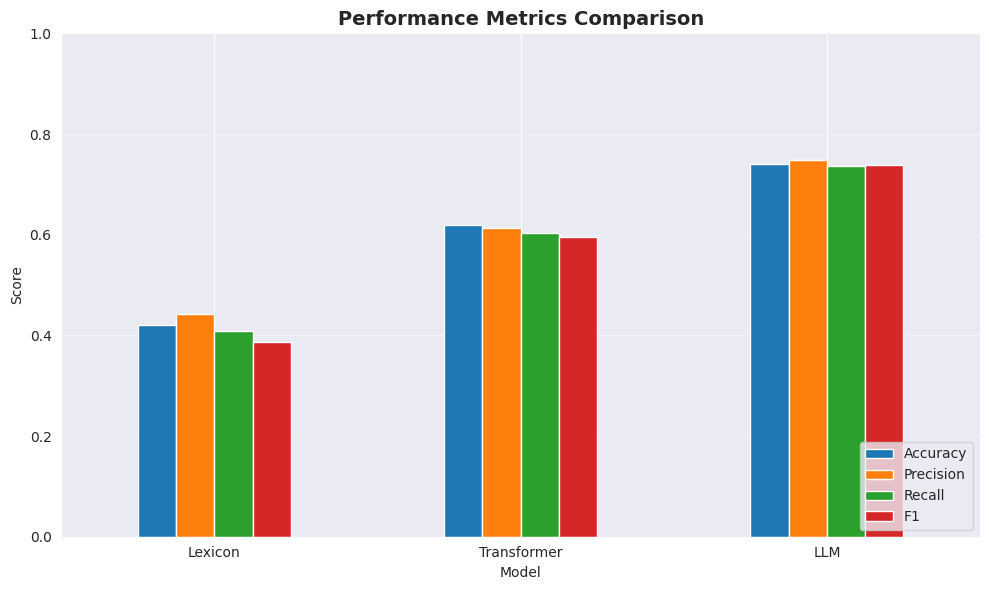

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

metrics_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': res['accuracy'],
        'Precision': res['precision'],
        'Recall': res['recall'],
        'F1': res['f1']
    }
    for name, res in all_results.items()
])

metrics_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1']].plot(
    kind='bar', ax=ax, rot=0
)
ax.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
def analyze_error_cases(results_dict, dataset, top_n=5):
    print("\n" + "="*80)
    print("ERROR ANALYSIS")
    print("="*80)

    for name, res in results_dict.items():
        print(f"\n{'─'*60}")
        print(f"📋 {name} Model")
        print(f"{'─'*60}")

        errors = []
        for i, (true, pred) in enumerate(zip(res['y_true'], res['y_pred'])):
            if true != pred:
                errors.append({
                    'index': i,
                    'text': dataset[i]['text'][:100],
                    'stars': dataset[i]['stars'],
                    'true': true,
                    'pred': pred
                })

        print(f"\nTotal Errors: {len(errors)}/{len(dataset)} ({len(errors)/len(dataset)*100:.1f}%)")

        print(f"\nSample Misclassifications:")
        for error in errors[:top_n]:
            print(f"\n  Review: \"{error['text']}...\"")
            print(f"  ⭐ Stars: {error['stars']} | True: {error['true']} | Predicted: {error['pred']}")

analyze_error_cases(all_results, ds, top_n=3)


ERROR ANALYSIS

────────────────────────────────────────────────────────────
📋 Lexicon Model
────────────────────────────────────────────────────────────

Total Errors: 58/100 (58.0%)

Sample Misclassifications:

  Review: "Ambiance was cozy...."
  ⭐ Stars: 4 | True: positive | Predicted: neutral

  Review: "The pizza was bland...."
  ⭐ Stars: 2 | True: negative | Predicted: neutral

  Review: "Coffee was okay...."
  ⭐ Stars: 3 | True: neutral | Predicted: positive

────────────────────────────────────────────────────────────
📋 Transformer Model
────────────────────────────────────────────────────────────

Total Errors: 38/100 (38.0%)

Sample Misclassifications:

  Review: "Great food but the service was slow...."
  ⭐ Stars: 4 | True: positive | Predicted: neutral

  Review: "Delicious ramen, mediocre gyoza, and the tea was cold...."
  ⭐ Stars: 3 | True: neutral | Predicted: negative

  Review: "The pasta was overcooked but the sauce was excellent; servers were attentive...."
  ⭐ Star